## Spaceship Titanic, Transported Passenger Prediction

### Project Overview
This project addresses the Kaggle Spaceship Titanic competition. The task is to predict whether each passenger was transported to an alternate dimension based on passenger profile, travel details, and onboard activity data. It is a supervised binary classification problem.

### Problem Statement
Given labeled passenger records in the training set and unlabeled records in the test set, the objective is to learn the relationship between input features and transport outcome, then generate accurate predictions for unseen passengers.

### Objective
The objective is to build a high performing classification pipeline that maximizes predictive accuracy on the competition test set while maintaining strong internal validation discipline.

### Target Variable
The target variable is Transported. It is a binary outcome with two classes, True and False.

### Evaluation Metric
The competition uses accuracy as the scoring metric. Model development should therefore focus on improving classification correctness while validating performance carefully to avoid leaderboard overfitting.

### Analytical Focus
The main analytical focus is to determine which passenger attributes, travel variables, and behavioral signals contribute most to transport prediction. Particular attention should be given to missing data structure, categorical relationships, and hidden signal in composite fields.

### Project Goal
The goal is to produce a professional competition solution with strong feature understanding, reliable validation, and a final model that is competitive on the leaderboard.

In [1]:
# 1. IMPORT LIARIES

# core data handling
import pandas as pd
import numpy as np

# Display settings for easier data inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
# 2. LOAD DATA

# Load the training and test datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission_df = pd.read_csv("sample_submission.csv")

In [3]:
# 3. SHAPE CHECK

# check the size of each dataset
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission_df.shape)

Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)


In [4]:
# 4. PREVIEW DATA

# preview the first few rows of each file
print("TRAIN DATA")
display(train_df.head())

print("TEST DATA")
display(test_df.head())

print("SAMPLE SUBMISSION")
display(sample_submission_df.head())

TRAIN DATA


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


TEST DATA


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


SAMPLE SUBMISSION


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [5]:
# 5. CHECK COLUMN NAMES

# view all column names
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission_df.columns.tolist())

Train columns:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Test columns:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']

Sample submission columns:
['PassengerId', 'Transported']


In [6]:
# 6. BASIC DATAFRAME INFO

# check data types and missing value presence at a high level
print("TRAIN INFO")
train_df.info()

print("\nTEST INFO")
test_df.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column  

In [7]:
# 7. MISSING VALUE ANALYSIS

# Calculate missing value count and percentage for the training dataset
train_missing = pd.DataFrame({
    "Missing_Count": train_df.isnull().sum(),
    "Missing_Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

# Sort training missing values from highest to lowest
train_missing = train_missing.sort_values(by="Missing_Percentage", ascending=False)

print("TRAIN DATA MISSING VALUES")
display(train_missing)


# Calculate missing value count and percentage for the test dataset
test_missing = pd.DataFrame({
    "Missing_Count": test_df.isnull().sum(),
    "Missing_Percentage": (test_df.isnull().sum() / len(test_df)) * 100
})

# Sort test missing values from highest to lowest
test_missing = test_missing.sort_values(by="Missing_Percentage", ascending=False)

print("TEST DATA MISSING VALUES")
display(test_missing)


# Extract passenger group from PassengerId
# Example: 0001_01 belongs to group 0001
train_df["Group"] = train_df["PassengerId"].str.split("_").str[0]
test_df["Group"] = test_df["PassengerId"].str.split("_").str[0]


# Count missing values per passenger group in the training data
missing_cols_train = train_df.columns[train_df.isnull().any()]

train_group_missing = train_df.groupby("Group")[missing_cols_train].apply(
    lambda x: x.isnull().sum()
)

print("TRAIN DATA MISSING VALUES BY PASSENGER GROUP")
display(train_group_missing.head(10))


# Check whether missing values in each column relate to the target variable
# This compares Transported rate for rows where a column is missing vs not missing
missing_target_relationship = {}

for col in missing_cols_train:
    missing_target_relationship[col] = train_df.groupby(train_df[col].isnull())["Transported"].mean()

print("RELATIONSHIP BETWEEN MISSING VALUES AND TRANSPORTED")
for col, result in missing_target_relationship.items():
    print(f"\nColumn: {col}")
    print(result)

TRAIN DATA MISSING VALUES


,Missing_Count,Missing_Percentage
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
Spa,183,2.105142
FoodCourt,183,2.105142
Destination,182,2.093639


TEST DATA MISSING VALUES


,Missing_Count,Missing_Percentage
FoodCourt,106,2.478373
Spa,101,2.361468
Cabin,100,2.338087
ShoppingMall,98,2.291326
Name,94,2.197802
VIP,93,2.174421
CryoSleep,93,2.174421
Destination,92,2.151040
Age,91,2.127660
HomePlanet,87,2.034136


TRAIN DATA MISSING VALUES BY PASSENGER GROUP


,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
Group,,,,,,,,,,,,
0001,0,0,0,0,0,0,0,0,0,0,0,0
0002,0,0,0,0,0,0,0,0,0,0,0,0
0003,0,0,0,0,0,0,0,0,0,0,0,0
0004,0,0,0,0,0,0,0,0,0,0,0,0
0005,0,0,0,0,0,0,0,0,0,0,0,0
0006,0,0,0,0,0,0,0,0,0,0,1,0
0007,0,0,0,0,0,0,0,0,0,0,0,0
0008,0,0,0,0,0,0,0,0,1,0,0,0
0009,0,0,0,0,0,0,0,0,0,0,0,0


RELATIONSHIP BETWEEN MISSING VALUES AND TRANSPORTED

Column: HomePlanet
HomePlanet
False    0.503415
True     0.512438
Name: Transported, dtype: float64

Column: CryoSleep
CryoSleep
False    0.504011
True     0.488479
Name: Transported, dtype: float64

Column: Cabin
Cabin
False    0.503650
True     0.502513
Name: Transported, dtype: float64

Column: Destination
Destination
False    0.503584
True     0.505495
Name: Transported, dtype: float64

Column: Age
Age
False    0.503641
True     0.502793
Name: Transported, dtype: float64

Column: VIP
VIP
False    0.503416
True     0.512315
Name: Transported, dtype: float64

Column: RoomService
RoomService
False    0.504582
True     0.458564
Name: Transported, dtype: float64

Column: FoodCourt
FoodCourt
False    0.502820
True     0.540984
Name: Transported, dtype: float64

Column: ShoppingMall
ShoppingMall
False    0.502534
True     0.548077
Name: Transported, dtype: float64

Column: Spa
Spa
False    0.503760
True     0.497268
Name: Transported, d

TARGET VARIABLE DISTRIBUTION


Transported
True     4378
False    4315
Name: count, dtype: int64

TARGET VARIABLE DISTRIBUTION (%)


Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

TRANSPORT RATE BY HOMEPLANET


...

CABIN SAMPLE VALUES


0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
5    F/0/P
6    F/2/S
7    G/0/S
8    F/3/S
9    B/1/P
Name: Cabin, dtype: object

MOST COMMON CABIN VALUES


Cabin
G/734/S     8
F/1194/P    7
B/201/P     7
G/981/S     7
G/109/P     7
C/21/P      7
D/176/S     7
C/137/S     7
B/11/S      7
G/1476/S    7
Name: count, dtype: int64

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>,
        <Axes: title={'center': 'FoodCourt'}>],
       [<Axes: title={'center': 'ShoppingMall'}>,
        <Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>],
       [<Axes: title={'center': 'TotalSpend'}>, <Axes: >, <Axes: >]],
      dtype=object)

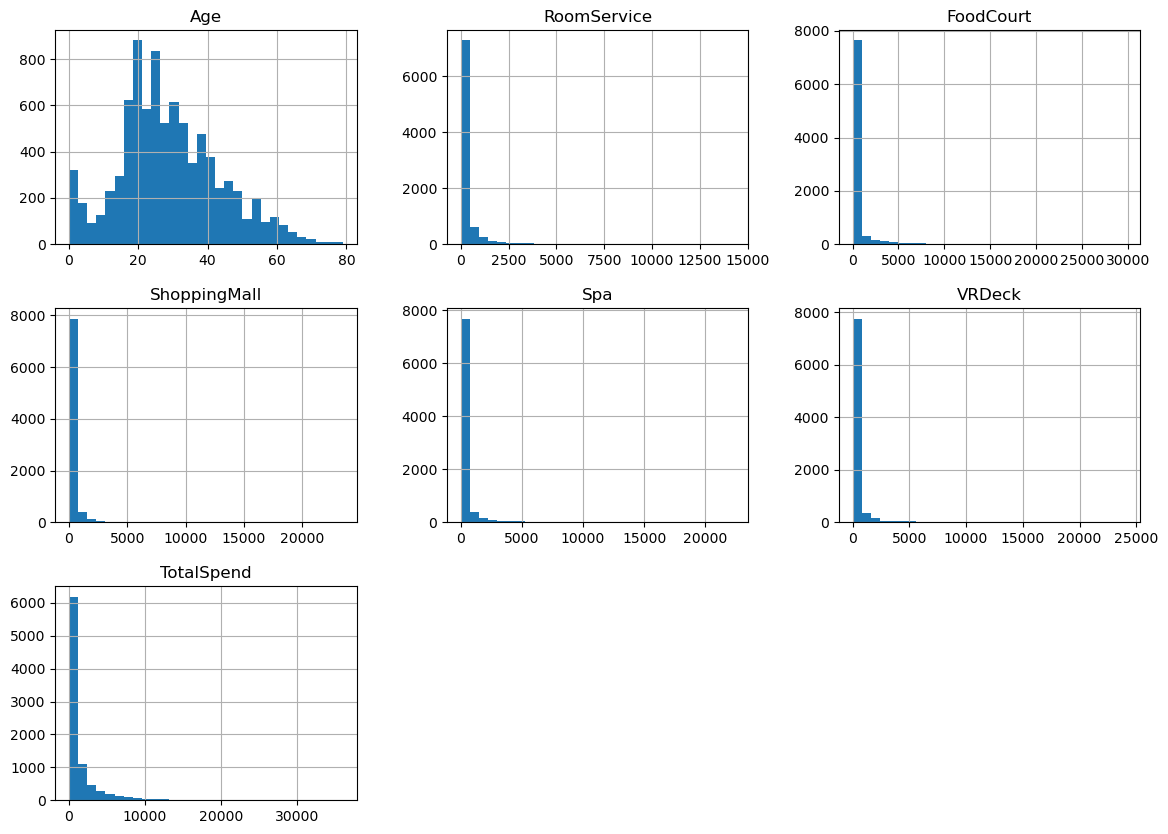

In [8]:
# 8. EXPLORATORY DATA ANALYSIS (EDA)

# Check the target variable distribution
# This shows the wheater the classes are balanced or imbalanced
print("TARGET VARIABLE DISTRIBUTION")
display(train_df["Transported"].value_counts())

print("TARGET VARIABLE DISTRIBUTION (%)")
display(train_df["Transported"].value_counts(normalize=True) * 100)

# Check transport rate by HomePlanet
print("TRANSPORT RATE BY HOMEPLANET")
display(
    train_df.groupby("HomePlanet")["Transported"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

# Check transport rate by Destination
print("TRANSPORT RATE BY DESTINATION")
display(
    train_df.groupby("Destination")["Transported"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

# Check transport rate by VIP status
print("TRANSPORT RATE BY VIP STATUS")
display(
    train_df.groupby("VIP")["Transported"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

# Summary statistics for numerical columns
num_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

print("NUMERICAL FEATRUE SUMMARY")
display(train_df[num_cols].describe())

# Compare average numerical values by Transported outcome
print("NUMERICAL FEATURES BY TRANSPORTED")
display(
    train_df.groupby("Transported")[num_cols]
    .mean()
)

# Create total spending column for exploration
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train_df["TotalSpend"] = train_df[spending_cols].sum(axis=1)

print("TOTAL SPENDING SUMMARY")
display(train_df["TotalSpend"].describe())

# Compare total spending by Transported outcome
print("TOTAL SPENDING BY TRANSPORTED")
display(
    train_df.groupby("Transported")["TotalSpend"]
    .agg(["count", "mean", "median", "max"])
)

# Check whether spending nothing relates to Transported
train_df["NoSpend"] = train_df["TotalSpend"] == 0

print("TRANSPORT RATE BY SPENDING STATUS")
display(
    train_df.groupby("NoSpend")["Transported"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

# Inspect Cabin format before feature engineering
print("CABIN SAMPLE VALUES")
display(train_df["Cabin"].head(10))

# Check the most common cabin values
print("MOST COMMON CABIN VALUES")
display(train_df["Cabin"].value_counts().head(10))

# Basic histogram for numerical columns
# These help show the shape of numerical variables and possible outliers
train_df[num_cols + ["TotalSpend"]].hist(figsize=(14, 10), bins=30)